# TensorFlow를 활용한 로지스틱 회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 로지스틱 회귀문제를 풀어봅니다.
여기서는 iris 데이터셋을 사용하여 꽃의 종류를 분류하는 예제를 다룹니다.

## 주요 단계
1. 데이터 불러오기 및 전처리
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(tf.__version__)

2.21.0


## 1. 데이터 불러오기 및 전처리

In [2]:
# ----------------------
# 1. 데이터 불러오기
# ----------------------
iris = load_iris()
X = iris.data[:, :2]  # 꽃받침 길이, 꽃받침 너비 (2개 feature만 사용해서 시각화 쉽게)
y = (iris.target == 0).astype(np.float32)  # Setosa = 1, Others = 0

print("X shape:", X.shape, "y shape:", y.shape)

# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X shape: (150, 2) y shape: (150,)


## 2. 모델 정의

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 3 (12.00 B)
 Trainable params: 3 (12.00 B)
 Non-trainable params: 0 (0.00 B)


## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [4]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

## 4. 모델 학습

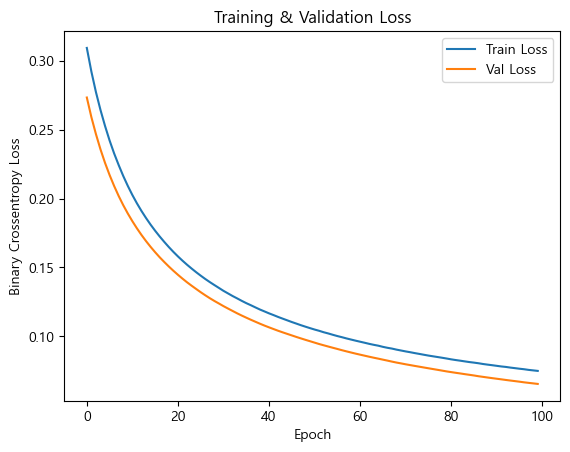

In [5]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_data=(X_test, y_test),
                    verbose=0)

# ----------------------
# 5. 학습 곡선 확인
# ----------------------
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

## 5. 결과 확인

테스트 정확도: 1.000


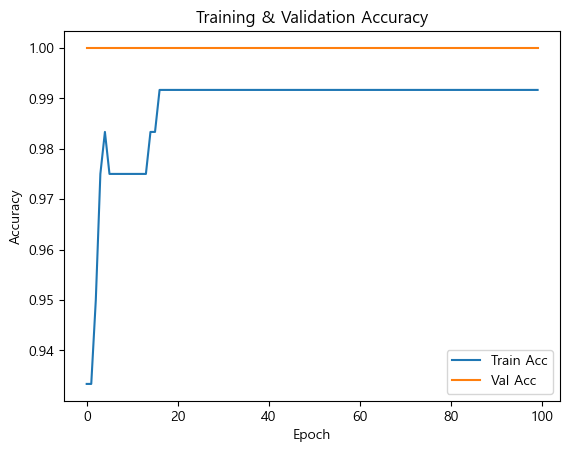

In [6]:
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

# ----------------------
# 6. 모델 평가
# ----------------------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {acc:.3f}")


   1/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step
 169/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step
 343/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step
 503/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step
 679/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step
 848/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step
1026/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step
1196/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 294us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step


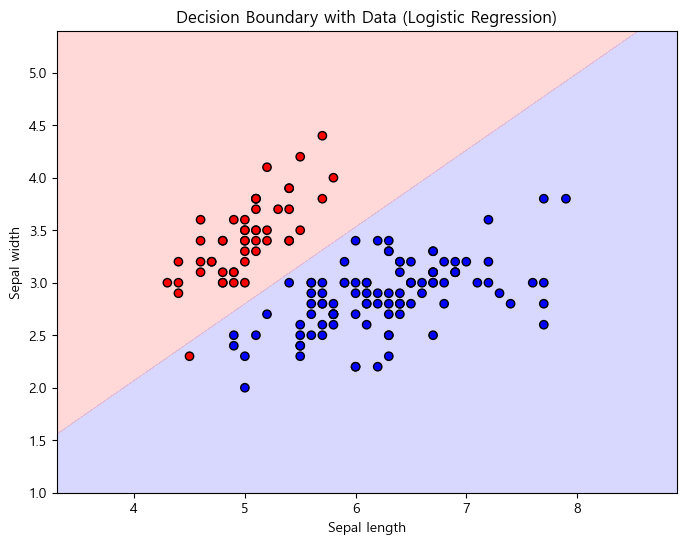

In [7]:
# ----------------------
# 결정 경계 + 전체 데이터 시각화
# ----------------------
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)
probs = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))

# 결정 경계 (배경 색)
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.3, cmap="bwr")

# 전체 데이터 산점도 (훈련+테스트)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Decision Boundary with Data (Logistic Regression)")
plt.show()

## 생각해보기
- 로지스틱 회귀 모델과 선형 회귀 모델의 차이는?

- **목적 및 출력값**: 선형 회귀는 연속적인 수치(연속형 값)를 예측하는 것이 목적으로 출력값의 범위에 제한이 없는($-\infty \sim \infty$) 반면, 로지스틱 회귀는 특정 클래스에 속할 **확률값($0 \sim 1$)**을 추정하여 범주를 구분하는 **분류(Classification)** 모델입니다.
- **모델 구조(활성화 함수)**: 선형 회귀는 입력의 선형 결합($z=Wx+b$)을 그대로 출력으로 사용하지만, 로지스틱 회귀는 선형 결합 결과를 **시그모이드(Sigmoid) 함수** $\sigma(z) = \frac{1}{1 + e^{-z}}$에 통과시켜 $0 \sim 1$ 사이의 확률값으로 변환합니다.
- **손실 함수(Loss Function)**: 선형 회귀는 오차의 제곱을 다루는 MSE(Mean Squared Error)를 사용해도 손실 곡면이 볼록(Convex)하지만, 시그모이드가 포함된 로지스틱 회귀에 MSE를 적용하면 비볼록(Non-convex) 형태가 되어 로컬 미니멈에 빠지기 쉽습니다. 따라서 로지스틱 회귀는 확률적 로그 우도에 기반한 **Binary Crossentropy(Log Loss)**를 손실 함수로 사용하여 안정적인 경사하강 수렴을 유도합니다.


- Learning Rate(학습률)의 역할은 무엇인가요?
- 너무 크거나 너무 작은 학습률을 사용하면 어떤 일이 발생하나?

학습률(Learning Rate, $\eta$)은 경사하강법에서 손실 함수의 기울기(Gradient) 반대 방향으로 가중치를 갱신할 때, 한 번의 스텝에서 얼마만큼 이동할 것인지를 결정하는 **보폭(Step size)** 파라미터입니다.

- **학습률이 너무 큰 경우**: 최적의 손실 지점(최솟값)을 지나쳐 튕겨 나가는 **오버슈팅(Overshooting)**이 발생합니다. 손실값이 최소점으로 수렴하지 못하고 진동(Oscillation)하거나 심한 경우 무한대(NaN/inf)로 발산해 버릴 수 있습니다.
- **학습률이 너무 작은 경우**: 한 스텝당 파라미터 변화량이 지나치게 미세하여 최적점에 도달하기까지 매우 많은 에폭과 계산 시간이 소요됩니다. 또한 정해진 학습 횟수 내에 충분히 수렴하지 못하거나, 기울기가 완만한 평탄 구간(Plateau) 또는 로컬 미니멈에 갇혀 성능 개선이 멈출 수 있습니다.
